<a href="https://colab.research.google.com/github/Jiyoung169/Uber_Review_Analysis/blob/main/Analysis_of_Uber_User_Reviews.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Comprehensive Analysis of Uber Customer Sentiment and Service Quality Trends (2025)**
* BAN200OBB: Sentiment Analysis and Text Mining
* Group3: Veronica Hoo, Vincent Le, Ivan Keov, Jiyoung Choi and Harsimran Singh


### **Project_Group3: Project Workflow & Role Distribution**
* Data Integration & Cleaning: Veronica
* Text Preprocessing: Vincent and Ivan
* Exploratory Data Analysis (EDA): Jiyoung and Harsimran

In [31]:
# Library Import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import kagglehub
import os

import tensorflow as tf
from tensorflow import keras
import re
import nltk
from nltk.stem import PorterStemmer, WordNetLemmatizer
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

!pip install google_play_scraper
from google_play_scraper import Sort, reviews
from datetime import datetime

**Webscraping: Veronica Hoo**

In [49]:
#Scrape user reviews from Google Play Store
app_id = 'com.ubercab'
all_reviews = []
continuation_token = None
target_date = datetime(2025, 1, 1)

while True:
    result, continuation_token = reviews(
        app_id,
        lang='en',
        country='us',
        sort=Sort.NEWEST,
        count=10000,
        continuation_token=continuation_token
    )
    all_reviews.extend(result)


    last_date = result[-1]['at']
    print(last_date)

    if last_date < target_date:
        break

    if not continuation_token:
        break

2026-03-12 12:54:45
2026-02-19 12:47:19
2026-01-28 07:53:04
2026-01-05 09:23:11
2025-12-14 02:06:02
2025-11-24 06:28:42
2025-11-07 03:05:23
2025-10-14 01:09:56
2025-09-20 12:41:42
2025-08-25 07:19:04
2025-08-03 12:17:37
2025-07-16 14:47:44
2025-07-01 12:16:05
2025-06-10 00:44:48
2025-05-19 14:43:53
2025-05-01 17:38:50
2025-04-13 09:03:23
2025-03-25 09:49:51
2025-03-04 11:19:32
2025-02-10 05:52:42
2025-01-20 17:16:03
2024-12-30 19:45:20


In [50]:
# Because the prior code retrieves reviews in batches, it may pull reviews
#... from 2024 and 2026. This further filters them to ensure accuracy.

# Convert the raw scraped list to pandas dataframe
df_uber_reviews = pd.DataFrame(all_reviews)

# Change review 'at' column to datetime format
df_uber_reviews['at'] = pd.to_datetime(df_uber_reviews['at'])

# Filter to show reviews from 2025 only
df_reviews_2025 = df_uber_reviews[
    (df_uber_reviews['at'] >= '2025-01-01') &
    (df_uber_reviews['at'] <= '2025-12-31')
].copy()

# Make sure that filtering was applied correctly
print(f"Original number of records scraped: {len(df_uber_reviews)}")
print(f"Number of records just from 2025: {len(df_reviews_2025)}")

Original number of records scraped: 220000
Number of records just from 2025: 177120


In [51]:
# Check that filtering (to 2025 data only) was completed successfully
df_reviews_2025.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
42405,6a6eeb34-cfce-4025-acfc-7a706abfe577,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,"great driver , knows the area and safe.",5,0,4.609.10005,2025-12-30 23:50:16,None,NaT,4.609.10005
42406,74f095a6-837c-4d33-bda4-5e8dcc22c311,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,The worst app of all,1,0,4.609.10005,2025-12-30 23:46:19,None,NaT,4.609.10005
42407,0d80ae69-6fa9-436f-998b-64f4afd9a7c6,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,seriously!!! are the people behind this app ju...,1,2,4.609.10005,2025-12-30 23:34:18,None,NaT,4.609.10005
42408,72a88391-cae5-4f2a-9e89-01a69237e605,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,Uber bringing the night life back to Winnipeg ...,5,0,4.609.10005,2025-12-30 23:32:53,None,NaT,4.609.10005
42409,eaadc7fe-4313-404c-8f39-3db80b4b56a8,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,"Every time I use this app, there's no cars in ...",1,0,4.609.10005,2025-12-30 23:32:38,None,NaT,4.609.10005


In [52]:
# Get the metadata of our filtered dataframe
df_reviews_2025.info()

<class 'pandas.core.frame.DataFrame'>
Index: 177120 entries, 42405 to 219524
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   reviewId              177120 non-null  object        
 1   userName              177120 non-null  object        
 2   userImage             177120 non-null  object        
 3   content               177120 non-null  object        
 4   score                 177120 non-null  int64         
 5   thumbsUpCount         177120 non-null  int64         
 6   reviewCreatedVersion  148378 non-null  object        
 7   at                    177120 non-null  datetime64[ns]
 8   replyContent          386 non-null     object        
 9   repliedAt             386 non-null     datetime64[ns]
 10  appVersion            148378 non-null  object        
dtypes: datetime64[ns](2), int64(2), object(7)
memory usage: 16.2+ MB


In [53]:
first_200_reviews = df_reviews_2025.head(200)
first_200_reviews.to_csv('first_200_reviews_2025.csv', index=False)
print('Successfully exported the first 200 reviews to first_200_reviews_2025.csv')

# Display the head of the exported data to verify
display(first_200_reviews.head())

Successfully exported the first 200 reviews to first_200_reviews_2025.csv


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
42405,6a6eeb34-cfce-4025-acfc-7a706abfe577,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,"great driver , knows the area and safe.",5,0,4.609.10005,2025-12-30 23:50:16,None,NaT,4.609.10005
42406,74f095a6-837c-4d33-bda4-5e8dcc22c311,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,The worst app of all,1,0,4.609.10005,2025-12-30 23:46:19,None,NaT,4.609.10005
42407,0d80ae69-6fa9-436f-998b-64f4afd9a7c6,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,seriously!!! are the people behind this app ju...,1,2,4.609.10005,2025-12-30 23:34:18,None,NaT,4.609.10005
42408,72a88391-cae5-4f2a-9e89-01a69237e605,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,Uber bringing the night life back to Winnipeg ...,5,0,4.609.10005,2025-12-30 23:32:53,None,NaT,4.609.10005
42409,eaadc7fe-4313-404c-8f39-3db80b4b56a8,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,"Every time I use this app, there's no cars in ...",1,0,4.609.10005,2025-12-30 23:32:38,None,NaT,4.609.10005


**Data Cleaning: Veronica Hoo**

In [54]:
# Drop the columns 'userName', 'userImage', 'reviewCreatedVersion', 'appVersion', 'replyContent', and 'repliedAt'
df_reviews_2025.drop(columns=['userName', 'userImage', 'reviewCreatedVersion', 'appVersion', 'replyContent', 'repliedAt'], inplace=True)

# Check to see if columns were dropped
df_reviews_2025.head()

,reviewId,content,score,thumbsUpCount,at
42405,6a6eeb34-cfce-4025-acfc-7a706abfe577,"great driver , knows the area and safe.",5,0,2025-12-30 23:50:16
42406,74f095a6-837c-4d33-bda4-5e8dcc22c311,The worst app of all,1,0,2025-12-30 23:46:19
42407,0d80ae69-6fa9-436f-998b-64f4afd9a7c6,seriously!!! are the people behind this app ju...,1,2,2025-12-30 23:34:18
42408,72a88391-cae5-4f2a-9e89-01a69237e605,Uber bringing the night life back to Winnipeg ...,5,0,2025-12-30 23:32:53
42409,eaadc7fe-4313-404c-8f39-3db80b4b56a8,"Every time I use this app, there's no cars in ...",1,0,2025-12-30 23:32:38


In [55]:
# Check for duplicate rows
duplicates = df_reviews_2025.duplicated(subset=['reviewId','content','score','thumbsUpCount','at']).sum()
print(duplicates)

# RESULT: No duplicate rows

0


In [56]:
# Find sum of missing values per column
df_reviews_2025.isnull().sum()

# RESULT: No missing values

,0
reviewId,0
content,0
score,0
thumbsUpCount,0
at,0


In [57]:
# Basic summary statistics:
# just gives info about score and thumbsUpCount and indicates if outliers are present
df_reviews_2025.describe()

# RESULT: No identified outliers

,score,thumbsUpCount,at
count,177120.000000,177120.000000,177120
mean,3.823679,0.722905,2025-06-29 19:19:40.679330816
min,1.000000,0.000000,2025-01-01 00:01:42
25%,2.000000,0.000000,2025-04-03 14:49:33.500000
50%,5.000000,0.000000,2025-06-29 10:02:30.500000
75%,5.000000,0.000000,2025-09-27 13:36:49.750000128
max,5.000000,8700.000000,2025-12-30 23:50:16
std,1.719121,33.973837,NaN


In [58]:
# Get the avg character length of the content/reviews

df_reviews_2025['review_len'] = df_reviews_2025['content'].apply(len)
avg_review_len = df_reviews_2025['review_len'].mean()
print(f"The average review length is: {avg_review_len:.2f} characters")

The average review length is: 63.69 characters



 **Text Preprocessing: Vincent and Ivan**



In [59]:
# Define cleaning function

nltk.download('wordnet')
nltk.download('omw-1.4')

stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

def advanced_clean_and_tokenize(text):


    # Convert to lowercase
    lowercase_text = text.lower()

    # Identify words with 2 or more characters
    tokens = re.findall(r'\b\w\w+\b', lowercase_text)

    # Filter out stop words to focus on meaningful content
    clean_tokens = [
        lemmatizer.lemmatize(t)
        for t in tokens
        if t not in ENGLISH_STOP_WORDS
    ]

    return " ".join(clean_tokens)

# Apply preprocessing
df_reviews_2025['clean_content'] = df_reviews_2025['content'].apply(advanced_clean_and_tokenize)



[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [60]:
# Sentiment Labeling for Supervised Learning

df_reviews_2025['label'] = df_reviews_2025['score'].map({5:1, 4:1, 2:0, 1:0})
df_reviews_2025 = df_reviews_2025.dropna(subset=['label'])
df_reviews_2025['label'] = df_reviews_2025['label'].astype(int)


In [61]:
# Preprocessing and Labeling
print(df_reviews_2025[['content', 'clean_content', 'label']].head())

                                                 content  \
42405            great driver , knows the area and safe.   
42406                               The worst app of all   
42407  seriously!!! are the people behind this app ju...   
42408  Uber bringing the night life back to Winnipeg ...   
42409  Every time I use this app, there's no cars in ...   

                                           clean_content  label  
42405                        great driver know area safe      1  
42406                                          worst app      0  
42407  seriously people app just genuinely stupid ord...      0  
42408  uber bringing night life winnipeg safe cost ef...      1  
42409  time use app car area taxi service disaster ub...      0  


**Exploratory Data Analysis(EDA): Jiyoung and Harsimran**

In [62]:
# Check the distribution of scores
score_distribution = df_reviews_2025['score'].value_counts().sort_index()
print(score_distribution)


score
1     43502
2      4762
4     10462
5    113597
Name: count, dtype: int64


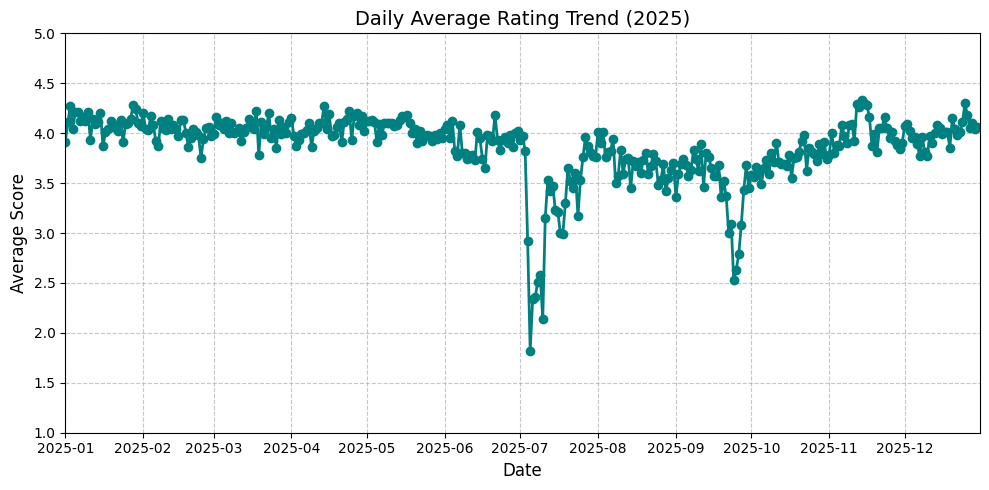

In [63]:

# Group by date from the 'at' column and calculate the mean score
daily_mean_score = df_reviews_2025.groupby(df_reviews_2025['at'].dt.date)['score'].mean()

# Visualization Setup
plt.figure(figsize=(10, 5))
daily_mean_score.plot(kind='line', marker='o', color='teal', linewidth=2)
plt.xlim(pd.Timestamp('2025-01-01'), pd.Timestamp('2025-12-31'))

plt.title('Daily Average Rating Trend (2025)', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Average Score', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=0)
plt.ylim(1, 5)
plt.tight_layout()
plt.show()

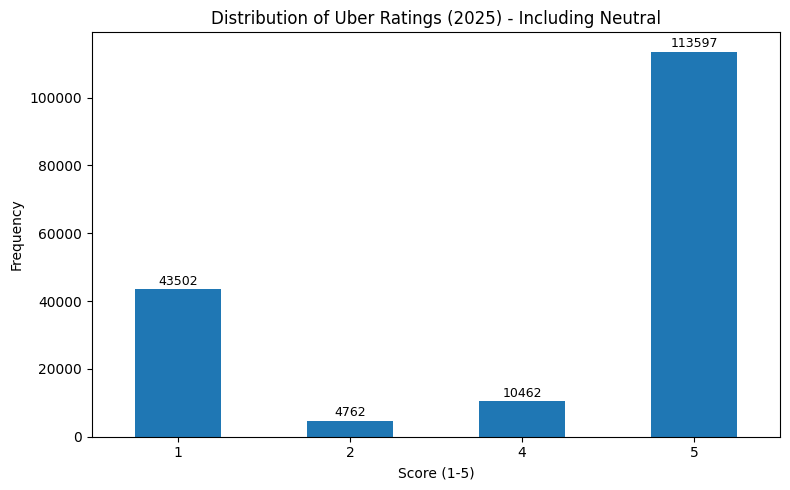

In [64]:

# Visualize Score Distribution
df_reviews_2025['label'] = df_reviews_2025['score'].map({
    5: 2, # Positive
    4: 2, # Positive
    3: 1, # Neutral
    2: 0, # Negative
    1: 0  # Negative
})

# Drop rows only if the label is truly missing
df_reviews_2025 = df_reviews_2025.dropna(subset=['label'])
df_reviews_2025['label'] = df_reviews_2025['label'].astype(int)


plt.figure(figsize=(8,5))
counts = df_reviews_2025['score'].value_counts().sort_index()
counts.plot(kind='bar')
plt.title('Distribution of Uber Ratings (2025) - Including Neutral')
plt.xlabel('Score (1-5)')
plt.ylabel('Frequency')
plt.xticks(rotation=0)

# Adding data labels on top of each bar
for i, v in enumerate(counts):
    plt.text(i, v + 500, str(v), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

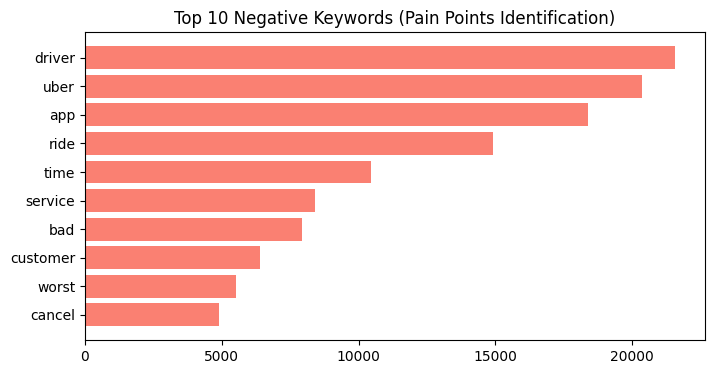

In [65]:
# Key Insights: Top 10 Keywords in Negative Reviews
# Analyzing the most frequent complaints (pain points)
negative_reviews = df_reviews_2025[df_reviews_2025['label'] == 0]['clean_content']
all_neg_words = " ".join(negative_reviews).split()
most_common_neg = Counter(all_neg_words).most_common(10)

words, counts = zip(*most_common_neg)
plt.figure(figsize=(8, 4))
plt.barh(words, counts, color='salmon')
plt.title('Top 10 Negative Keywords (Pain Points Identification)')
plt.gca().invert_yaxis()
plt.show()

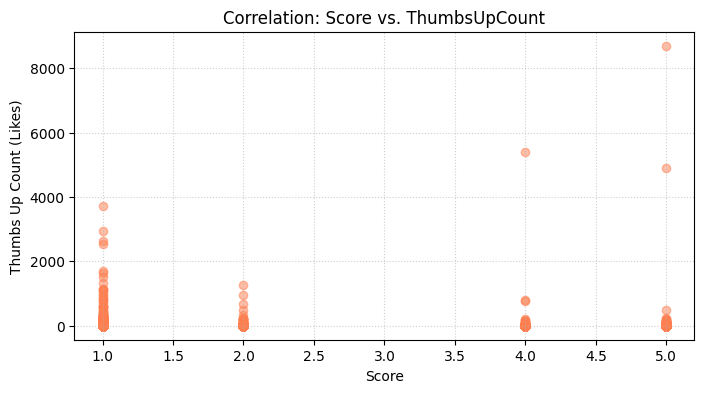

In [66]:
# Correlation Analysis: Score vs. ThumbsUpCount
# Analyze if impactful complaints (high likes) are associated with lower scores
plt.figure(figsize=(8, 4))
plt.scatter(df_reviews_2025['score'], df_reviews_2025['thumbsUpCount'], alpha=0.5, color='coral')
plt.title('Correlation: Score vs. ThumbsUpCount')
plt.xlabel('Score')
plt.ylabel('Thumbs Up Count (Likes)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [67]:
# Summary Statistics
print(df_reviews_2025[['score', 'thumbsUpCount']].describe())

               score  thumbsUpCount
count  172323.000000  172323.000000
mean        3.846608       0.709418
std         1.737307      33.841615
min         1.000000       0.000000
25%         1.000000       0.000000
50%         5.000000       0.000000
75%         5.000000       0.000000
max         5.000000    8700.000000


### **Deep Learning Sentiment Analysis Model**

In [68]:
# Prepare data
df_reviews_2025['label'] = df_reviews_2025['score'].map({5:1, 4:1, 2:0, 1:0})

df_reviews_2025 = df_reviews_2025.dropna(subset=['label'])
df_reviews_2025['label'] = df_reviews_2025['label'].astype(int)

X = df_reviews_2025['clean_content'].values
y = df_reviews_2025['label'].values

# Split into train/test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [69]:
# Text Vectorization
vectorizer = keras.layers.TextVectorization(max_tokens=10000, output_mode='int')
vectorizer.adapt(X_train)

In [70]:
# Build the Model
model = keras.Sequential([
    keras.Input(shape=(1,), dtype=tf.string),
    vectorizer,
    keras.layers.Embedding(input_dim=10000, output_dim=64),
    keras.layers.GlobalAveragePooling1D(),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(1, activation='sigmoid')
])

In [42]:
# Compile and Train with EarlyStopping
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# EarlyStopping to prevent overfitting
callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

model.fit(X_train, y_train, epochs=10, batch_size=32,
          validation_split=0.1, callbacks=[callback], verbose=1)

Epoch 1/10
3878/3878 ━━━━━━━━━━━━━━━━━━━━ 30s 7ms/step - accuracy: 0.9146 - loss: 0.2294 - val_accuracy: 0.9481 - val_loss: 0.1525
Epoch 2/10
3878/3878 ━━━━━━━━━━━━━━━━━━━━ 41s 7ms/step - accuracy: 0.9485 - loss: 0.1563 - val_accuracy: 0.9407 - val_loss: 0.1673
Epoch 3/10
3878/3878 ━━━━━━━━━━━━━━━━━━━━ 27s 7ms/step - accuracy: 0.9541 - loss: 0.1419 - val_accuracy: 0.9544 - val_loss: 0.1462
Epoch 4/10
3878/3878 ━━━━━━━━━━━━━━━━━━━━ 27s 7ms/step - accuracy: 0.9556 - loss: 0.1366 - val_accuracy: 0.9483 - val_loss: 0.1653
Epoch 5/10
3878/3878 ━━━━━━━━━━━━━━━━━━━━ 28s 7ms/step - accuracy: 0.9569 - loss: 0.1317 - val_accuracy: 0.9538 - val_loss: 0.1461
Epoch 6/10
3878/3878 ━━━━━━━━━━━━━━━━━━━━ 29s 7ms/step - accuracy: 0.9587 - loss: 0.1283 - val_accuracy: 0.9539 - val_loss: 0.1488
Epoch 7/10
3878/3878 ━━━━━━━━━━━━━━━━━━━━ 30s 8ms/step - accuracy: 0.9596 - loss: 0.1249 - val_accuracy: 0.9490 - val_loss: 0.1564
Epoch 8/10
3878/3878 ━━━━━━━━━━━━━━━━━━━━ 29s 7ms/step - accuracy: 0.9604 - loss: 0

In [44]:
# Evaluate
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy:.4f}")

1078/1078 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9526 - loss: 0.1471
Test Accuracy: 0.9526
